梯度下降解最小二乘

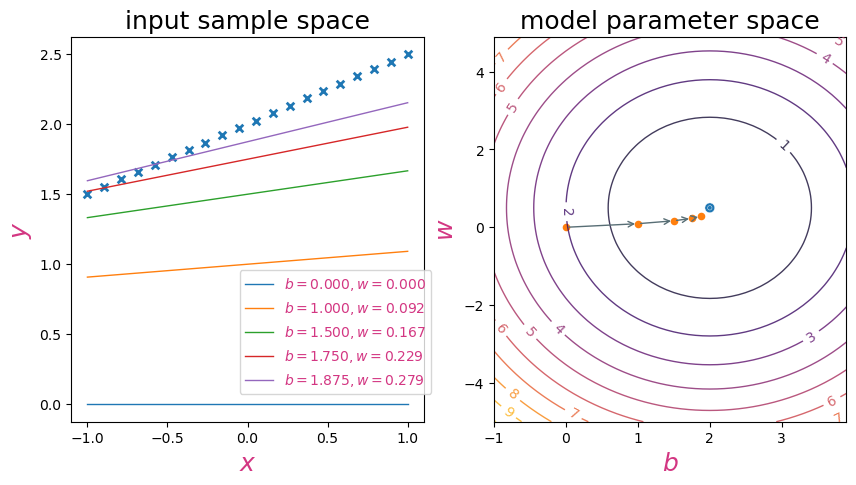

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


def hypothesis(x, b, w):
    return b + w * x


def cost_func2(b, w):  # 对(b,w) 计算当前总的平方损失
    b = np.atleast_3d(np.asarray(b))
    w = np.atleast_3d(np.asarray(w))
    return np.average((y - hypothesis(x, b, w))**2, axis=2) / 2


def cost_func(x, y, b, w):  # 最小二乘 平方损失
    res = x * w + b - y  # w可以是2x*的矩阵 y随其广播
    return np.sum(res**2, axis=0)


def grid(func, *args):  # 计算格点上的函数值 用于后续画等高线或热力图
    x_min, x_max, y_min, y_max = args
    grid_x, grid_y = np.meshgrid(np.linspace(x_min, x_max, 1000), np.linspace(y_min, y_max, 1000))
    grid_z = func(np.column_stack((grid_x.ravel(), grid_y.ravel())))
    grid_z = grid_z.reshape(grid_x.shape)
    return grid_x, grid_y, grid_z


b_true, w_true, m = 2, 0.5, 20
x = np.linspace(-1, 1, m)  # 20个样本 在[-1,1]上等距分布
y = b_true + w_true * x

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# 左图 样本
sns.scatterplot(x=x, y=y, lw=2, marker='x', legend=False, s=30, ax=ax[0])

# 右图 等高线
b_min, b_max, w_min, w_max = -1, 4, -5, 5

grid_b, grid_w, grid_z = grid()

b_grid = np.arange(-1, 4, 0.1)
w_grid = np.arange(-5, 5, 0.1)
J_grid = cost_func(b_grid[np.newaxis, :, np.newaxis], w_grid[:, np.newaxis, np.newaxis])
X, Y = np.meshgrid(b_grid, w_grid)
contours = ax[1].contour(X, Y, J_grid, 10, alpha=.8, linewidths=1, cmap='inferno')
ax[1].clabel(contours)
sns.scatterplot(x=[b_true] * 2, y=[w_true] * 2, legend=False, s=[50, 10], ax=ax[1])

N = 5  # 做5轮梯度下降
alpha = 0.5  # 梯度下降的步长
theta = [np.array((0, 0))]  # 初始解
J = [cost_func(*theta[0])[0]]  # 记录每轮的目标函数值
for j in range(N - 1):
    last_theta = theta[-1]  # 上一轮的解
    this_theta = np.empty((2,))

    # 根据上一轮的解对b和w做梯度下降
    this_theta[0] = last_theta[0] - alpha / m * np.sum((hypothesis(x, *last_theta) - y))
    this_theta[1] = last_theta[1] - alpha / m * np.sum((hypothesis(x, *last_theta) - y) * x)

    theta.append(this_theta)
    J.append(cost_func(*this_theta))

for j in range(0, N):  # 左图 每轮(b,w)对应的直线
    sns.lineplot(x=x, y=hypothesis(x, *theta[j]), lw=1, label=r'$b = {:.3f}, w = {:.3f}$'.format(*theta[j]), ax=ax[0])

for j in range(1, N):  # 右图 相邻两轮(b,w)之间画箭头
    ax[1].annotate('', xy=theta[j], xytext=theta[j - 1], arrowprops={'arrowstyle': '->', 'lw': 1, 'color': '#586e75'}, va='center', ha='center')

theta = np.array(theta)
sns.scatterplot(x=theta[:, 0], y=theta[:, 1], s=30, lw=0, legend=False, ax=ax[1])

ax[1].set_xlabel('$b$', color='#d33682', fontsize='18')
ax[1].set_ylabel('$w$', color='#d33682', fontsize='18')
ax[0].set_xlabel('$x$', color='#d33682', fontsize='18')
ax[0].set_ylabel('$y$', color='#d33682', fontsize='18')
axbox = ax[0].get_position()
ax[0].legend(loc=(axbox.x0 + axbox.width, axbox.y0 - 0.05 * axbox.height), labelcolor='#d33682')

ax[0].set_title('input sample space', size=18)
ax[1].set_title('model parameter space', size=18)

plt.show()

In [10]:
import numpy as np

theta = [np.array((0, 0))]
theta.append(np.array((1, 1)))
theta.append(np.array((2, 2)))

print(theta)
theta = np.array(theta)
print(theta)
print(theta[:,0])
print(theta[:,1])

[array([0, 0]), array([1, 1]), array([2, 2])]
[[0 0]
 [1 1]
 [2 2]]
[0 1 2]
[0 1 2]
